<a href="https://colab.research.google.com/github/MOHDVAZI4/college_labsheet_computervision/blob/main/labhseet3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Screenshot 2026-10-09 231748.png to Screenshot 2026-10-09 231748.png
OpenCV version: 5.0.0
Setup complete!


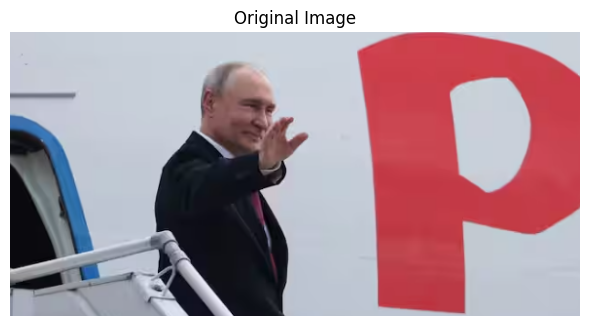

In [1]:

import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from skimage.metrics import structural_similarity as ssim
from IPython.display import display, clear_output
import ipywidgets as widgets
from google.colab import files

plt.rcParams["figure.figsize"] = (12, 6)

def load_image():
    uploaded = files.upload()
    filename = next(iter(uploaded))
    data = np.frombuffer(uploaded[filename], np.uint8)
    img = cv2.imdecode(data, cv2.IMREAD_COLOR)

    if img is None:
        raise ValueError("Could not read image")

    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

def show_images(images, titles, figsize=(16, 5)):
    plt.figure(figsize=figsize)

    for i, (img, title) in enumerate(
        zip(images, titles), 1
    ):
        plt.subplot(1, len(images), i)

        if len(img.shape) == 2:
            plt.imshow(img, cmap="gray")
        else:
            plt.imshow(img)

        plt.title(title)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

def add_salt_pepper_noise(image, amount=10, seed=42):
    rng = np.random.default_rng(seed)
    noisy = image.copy()
    h, w = image.shape[:2]
    n = int(h * w * amount / 100)

    rows = rng.integers(0, h, n)
    cols = rng.integers(0, w, n)
    half = n // 2

    noisy[rows[:half], cols[:half]] = 255
    noisy[rows[half:], cols[half:]] = 0

    return noisy

def calculate_psnr(original, filtered):
    original = original.astype(np.float64)
    filtered = filtered.astype(np.float64)

    mse = np.mean((original - filtered) ** 2)

    if mse == 0:
        return float("inf")

    return 10 * np.log10((255 ** 2) / mse)

def calculate_ssim(original, filtered):
    return ssim(
        original, filtered,
        channel_axis=2, data_range=255
    )

image = load_image()

print("OpenCV version:", cv2.__version__)
print("Setup complete!")
show_images([image], ["Original Image"], figsize=(6, 4))


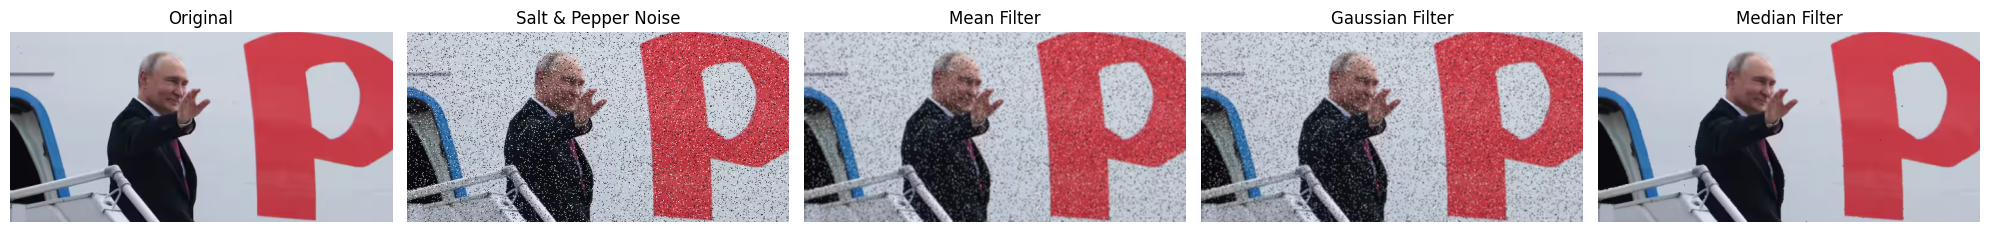

In [2]:

program1_image = image

noise_amount = 10
noisy = add_salt_pepper_noise(
    program1_image, noise_amount
)

noisy_bgr = cv2.cvtColor(
    noisy, cv2.COLOR_RGB2BGR
)

kernel_size = 3

# Mean Filter
mean_result = cv2.blur(
    noisy_bgr, (kernel_size, kernel_size)
)

# Gaussian Filter
gaussian_result = cv2.GaussianBlur(
    noisy_bgr, (kernel_size, kernel_size), 0
)

# Median Filter
median_result = cv2.medianBlur(
    noisy_bgr, kernel_size
)

mean_rgb = cv2.cvtColor(
    mean_result, cv2.COLOR_BGR2RGB
)
gaussian_rgb = cv2.cvtColor(
    gaussian_result, cv2.COLOR_BGR2RGB
)
median_rgb = cv2.cvtColor(
    median_result, cv2.COLOR_BGR2RGB
)

show_images(
    [program1_image, noisy, mean_rgb,
     gaussian_rgb, median_rgb],
    ["Original", "Salt & Pepper Noise",
     "Mean Filter", "Gaussian Filter",
     "Median Filter"],
    figsize=(20, 5)
)


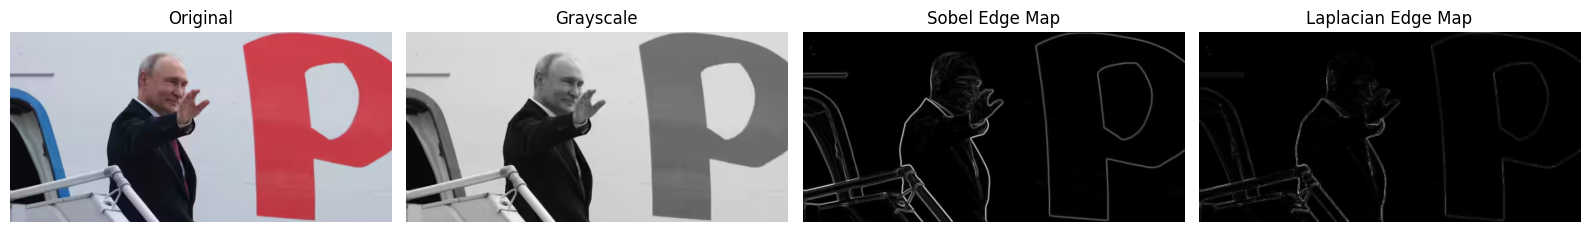

Sobel X kernel:
[[-1  0  1]
 [-2  0  2]
 [-1  0  1]]

Laplacian kernel:
[[ 0  1  0]
 [ 1 -4  1]
 [ 0  1  0]]


In [3]:

program2_image = image

gray = cv2.cvtColor(
    program2_image, cv2.COLOR_RGB2GRAY
)

# Sobel edge detection
sobel_x = cv2.Sobel(
    gray, cv2.CV_64F, 1, 0, ksize=3
)
sobel_y = cv2.Sobel(
    gray, cv2.CV_64F, 0, 1, ksize=3
)

sobel_magnitude = np.sqrt(
    sobel_x ** 2 + sobel_y ** 2
)

sobel_edges = cv2.normalize(
    sobel_magnitude, None, 0, 255,
    cv2.NORM_MINMAX
).astype(np.uint8)

# Laplacian edge detection
laplacian = cv2.Laplacian(
    gray, cv2.CV_64F, ksize=3
)

laplacian_edges = cv2.normalize(
    np.abs(laplacian), None, 0, 255,
    cv2.NORM_MINMAX
).astype(np.uint8)

show_images(
    [program2_image, gray,
     sobel_edges, laplacian_edges],
    ["Original", "Grayscale",
     "Sobel Edge Map", "Laplacian Edge Map"],
    figsize=(16, 5)
)

print("Sobel X kernel:")
print(np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
]))

print("\nLaplacian kernel:")
print(np.array([
    [0, 1, 0],
    [1, -4, 1],
    [0, 1, 0]
]))


In [4]:

program3_image = image

def interactive_blur(img):
    slider = widgets.IntSlider(
        value=5,
        min=3,
        max=31,
        step=2,
        description="Kernel:",
        continuous_update=True
    )

    output = widgets.Output()

    def update(change=None):
        with output:
            clear_output(wait=True)

            k = slider.value

            blurred = cv2.blur(
                img, (k, k)
            )

            show_images(
                [img, blurred],
                ["Original",
                 f"Mean Low-Pass Blur ({k}x{k})"],
                figsize=(12, 5)
            )

    slider.observe(update, names="value")

    display(slider, output)
    update()

interactive_blur(program3_image)


IntSlider(value=5, description='Kernel:', max=31, min=3, step=2)

Output()

In [5]:

program4_image = image

def interactive_unsharp(img):
    kernel_slider = widgets.IntSlider(
        value=5,
        min=3,
        max=31,
        step=2,
        description="Kernel:"
    )

    strength_slider = widgets.FloatSlider(
        value=1.5,
        min=0,
        max=5,
        step=0.1,
        description="Strength:"
    )

    output = widgets.Output()

    def update(change=None):
        with output:
            clear_output(wait=True)

            k = kernel_slider.value
            strength = strength_slider.value

            blurred = cv2.GaussianBlur(
                img, (k, k), 0
            )

            sharpened = cv2.addWeighted(
                img, 1 + strength,
                blurred, -strength, 0
            )

            sharpened = np.clip(
                sharpened, 0, 255
            ).astype(np.uint8)

            show_images(
                [img, blurred, sharpened],
                ["Original",
                 f"Gaussian Blur ({k}x{k})",
                 f"Unsharp Masking ({strength:.1f})"],
                figsize=(16, 5)
            )

    kernel_slider.observe(update, names="value")
    strength_slider.observe(update, names="value")

    display(kernel_slider, strength_slider, output)
    update()

interactive_unsharp(program4_image)


IntSlider(value=5, description='Kernel:', max=31, min=3, step=2)

FloatSlider(value=1.5, description='Strength:', max=5.0)

Output()

In [6]:

program5_image = image

def apply_custom_kernel(img, kernel):
    image_bgr = cv2.cvtColor(
        img, cv2.COLOR_RGB2BGR
    )

    result = cv2.filter2D(
        image_bgr, -1,
        kernel.astype(np.float32)
    )

    return cv2.cvtColor(
        result, cv2.COLOR_BGR2RGB
    )

preset_kernels = {
    "Identity": np.array([
        [0, 0, 0],
        [0, 1, 0],
        [0, 0, 0]
    ], dtype=np.float32),

    "Blur": np.ones(
        (3, 3), dtype=np.float32
    ) / 9,

    "Sharpen": np.array([
        [0, -1, 0],
        [-1, 5, -1],
        [0, -1, 0]
    ], dtype=np.float32),

    "Edge Detection": np.array([
        [-1, -1, -1],
        [-1, 8, -1],
        [-1, -1, -1]
    ], dtype=np.float32),

    "Sobel X": np.array([
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1]
    ], dtype=np.float32),

    "Sobel Y": np.array([
        [-1, -2, -1],
        [0, 0, 0],
        [1, 2, 1]
    ], dtype=np.float32),

    "Emboss": np.array([
        [-2, -1, 0],
        [-1, 1, 1],
        [0, 1, 2]
    ], dtype=np.float32)
}

preset_dropdown = widgets.Dropdown(
    options=list(preset_kernels.keys()),
    description="Preset:"
)

kernel_text = widgets.Textarea(
    value=np.array2string(
        preset_kernels["Identity"],
        separator=" "
    ),
    description="Kernel:",
    layout=widgets.Layout(
        width="500px", height="120px"
    )
)

button = widgets.Button(
    description="Apply Kernel",
    button_style="primary"
)

output = widgets.Output()

def parse_kernel(text):
    rows = []

    for line in text.strip().splitlines():
        line = line.replace("[", "").replace("]", "")
        values = [
            float(x)
            for x in line.replace(",", " ").split()
        ]

        if values:
            rows.append(values)

    if not rows:
        raise ValueError("Kernel is empty.")

    if len(set(len(row) for row in rows)) != 1:
        raise ValueError("Kernel rows must have equal lengths.")

    kernel = np.array(rows, dtype=np.float32)

    if kernel.shape[0] != kernel.shape[1]:
        raise ValueError("Kernel must be square.")

    if kernel.shape[0] % 2 == 0:
        raise ValueError("Kernel size must be odd.")

    return kernel

def update_kernel_text(change):
    kernel = preset_kernels[change["new"]]
    kernel_text.value = np.array2string(
        kernel, separator=" "
    )

def apply_kernel(_):
    with output:
        clear_output(wait=True)

        try:
            kernel = parse_kernel(kernel_text.value)
            result = apply_custom_kernel(
                program5_image, kernel
            )

            print("Kernel:")
            print(kernel)

            show_images(
                [program5_image, result],
                ["Original", "Custom Convolution Result"],
                figsize=(12, 5)
            )

        except Exception as e:
            print("Error:", e)

preset_dropdown.observe(
    update_kernel_text, names="value"
)

button.on_click(apply_kernel)

display(
    preset_dropdown,
    kernel_text,
    button,
    output
)


Dropdown(description='Preset:', options=('Identity', 'Blur', 'Sharpen', 'Edge Detection', 'Sobel X', 'Sobel Y'…

Textarea(value='[[0. 0. 0.]\n [0. 1. 0.]\n [0. 0. 0.]]', description='Kernel:', layout=Layout(height='120px', …

Button(button_style='primary', description='Apply Kernel', style=ButtonStyle())

Output()

In [7]:

program6_image = image

def interactive_bilateral_comparison(img):
    gaussian_k = widgets.IntSlider(
        value=9, min=3, max=31, step=2,
        description="Gaussian:"
    )

    gaussian_sigma = widgets.FloatSlider(
        value=2.0, min=0.1, max=10, step=0.1,
        description="G Sigma:"
    )

    bilateral_d = widgets.IntSlider(
        value=9, min=3, max=15, step=2,
        description="Bilateral:"
    )

    sigma_color = widgets.IntSlider(
        value=75, min=1, max=150, step=1,
        description="Sigma Color:"
    )

    sigma_space = widgets.IntSlider(
        value=75, min=1, max=150, step=1,
        description="Sigma Space:"
    )

    output = widgets.Output()

    def update(change=None):
        with output:
            clear_output(wait=True)

            g = cv2.GaussianBlur(
                img,
                (gaussian_k.value, gaussian_k.value),
                gaussian_sigma.value
            )

            bgr = cv2.cvtColor(
                img, cv2.COLOR_RGB2BGR
            )

            b = cv2.bilateralFilter(
                bgr,
                bilateral_d.value,
                sigma_color.value,
                sigma_space.value
            )

            b = cv2.cvtColor(
                b, cv2.COLOR_BGR2RGB
            )

            show_images(
                [img, g, b],
                ["Original", "Gaussian Blur",
                 "Bilateral Filter"],
                figsize=(16, 5)
            )

    for w in [
        gaussian_k, gaussian_sigma,
        bilateral_d, sigma_color, sigma_space
    ]:
        w.observe(update, names="value")

    display(
        gaussian_k, gaussian_sigma,
        bilateral_d, sigma_color,
        sigma_space, output
    )

    update()

interactive_bilateral_comparison(program6_image)


IntSlider(value=9, description='Gaussian:', max=31, min=3, step=2)

FloatSlider(value=2.0, description='G Sigma:', max=10.0, min=0.1)

IntSlider(value=9, description='Bilateral:', max=15, min=3, step=2)

IntSlider(value=75, description='Sigma Color:', max=150, min=1)

IntSlider(value=75, description='Sigma Space:', max=150, min=1)

Output()

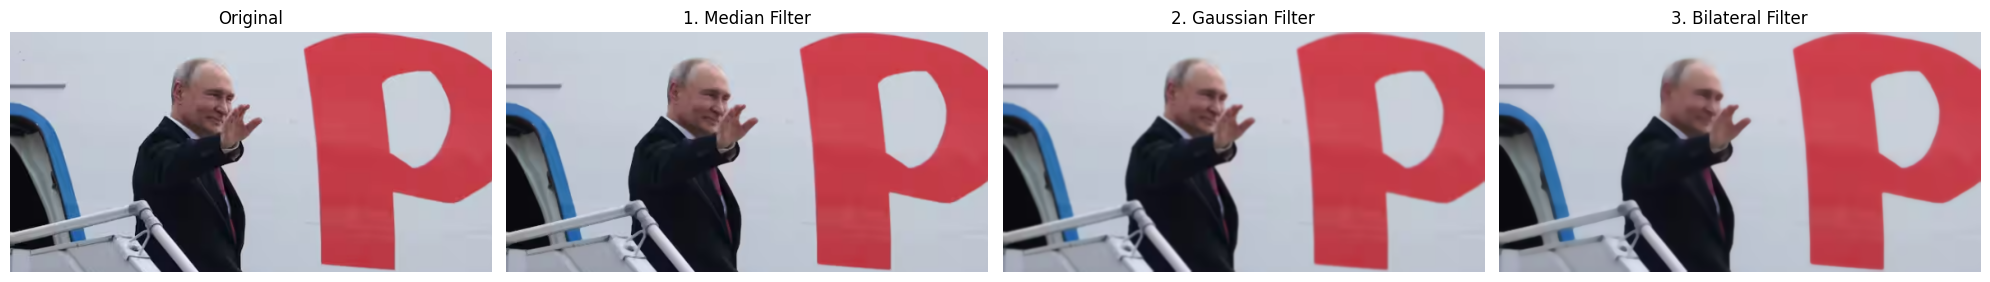

In [8]:

program7_image = image

def denoising_pipeline(
    img,
    median_k=3,
    gaussian_k=5,
    gaussian_sigma=1.0,
    bilateral_d=9,
    sigma_color=50,
    sigma_space=50
):
    bgr = cv2.cvtColor(
        img, cv2.COLOR_RGB2BGR
    )

    # Stage 1: Median filter
    stage1 = cv2.medianBlur(
        bgr, median_k
    )

    # Stage 2: Gaussian filter
    stage2 = cv2.GaussianBlur(
        stage1,
        (gaussian_k, gaussian_k),
        gaussian_sigma
    )

    # Stage 3: Bilateral filter
    stage3 = cv2.bilateralFilter(
        stage2,
        bilateral_d,
        sigma_color,
        sigma_space
    )

    return [
        img,
        cv2.cvtColor(stage1, cv2.COLOR_BGR2RGB),
        cv2.cvtColor(stage2, cv2.COLOR_BGR2RGB),
        cv2.cvtColor(stage3, cv2.COLOR_BGR2RGB)
    ]

pipeline_images = denoising_pipeline(
    program7_image
)

show_images(
    pipeline_images,
    ["Original", "1. Median Filter",
     "2. Gaussian Filter", "3. Bilateral Filter"],
    figsize=(20, 5)
)


In [9]:

program8_image = image

def high_pass_sharpen(
    img, kernel_size=5, sigma=1.0, strength=1.5
):
    blurred = cv2.GaussianBlur(
        img, (kernel_size, kernel_size), sigma
    )

    high_pass = (
        img.astype(np.float32)
        - blurred.astype(np.float32)
    )

    sharpened = (
        img.astype(np.float32)
        + strength * high_pass
    )

    sharpened = np.clip(
        sharpened, 0, 255
    ).astype(np.uint8)

    high_pass_display = cv2.normalize(
        np.abs(high_pass), None, 0, 255,
        cv2.NORM_MINMAX
    ).astype(np.uint8)

    return blurred, high_pass_display, sharpened


def interactive_motion_sharpen(img):
    kernel_slider = widgets.IntSlider(
        value=5, min=3, max=31, step=2,
        description="Kernel:"
    )

    sigma_slider = widgets.FloatSlider(
        value=1.0, min=0.1, max=10, step=0.1,
        description="Sigma:"
    )

    strength_slider = widgets.FloatSlider(
        value=1.5, min=0, max=5, step=0.1,
        description="Strength:"
    )

    output = widgets.Output()

    def update(change=None):
        with output:
            clear_output(wait=True)

            blurred, high_pass, sharpened = high_pass_sharpen(
                img,
                kernel_slider.value,
                sigma_slider.value,
                strength_slider.value
            )

            show_images(
                [img, high_pass, sharpened],
                ["Input", "High-Pass Detail",
                 "Sharpened Output"],
                figsize=(16, 5)
            )

    for w in [
        kernel_slider, sigma_slider, strength_slider
    ]:
        w.observe(update, names="value")

    display(
        kernel_slider, sigma_slider,
        strength_slider, output
    )

    update()

interactive_motion_sharpen(program8_image)


IntSlider(value=5, description='Kernel:', max=31, min=3, step=2)

FloatSlider(value=1.0, description='Sigma:', max=10.0, min=0.1)

FloatSlider(value=1.5, description='Strength:', max=5.0)

Output()

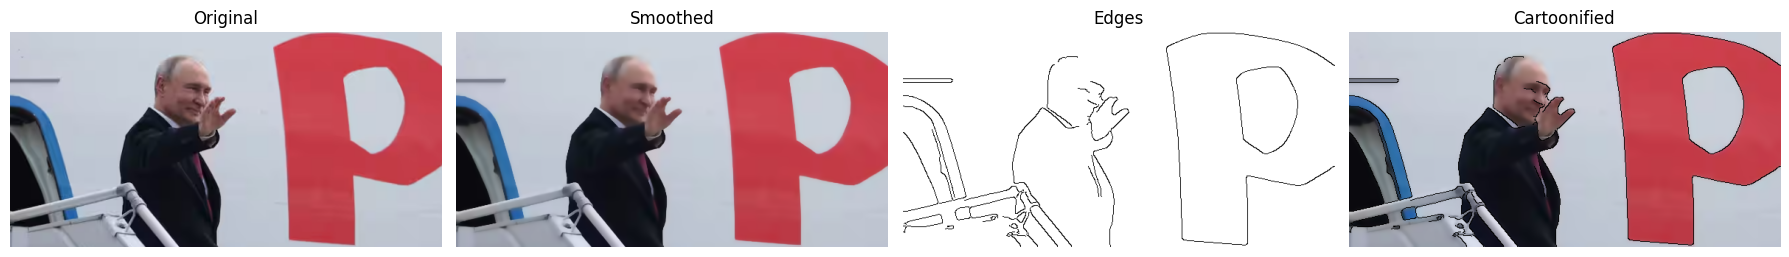

In [10]:

program9_image = image

def cartoonify(
    img,
    bilateral_d=9,
    sigma_color=75,
    sigma_space=75,
    median_k=5,
    threshold1=100,
    threshold2=200
):
    bgr = cv2.cvtColor(
        img, cv2.COLOR_RGB2BGR
    )

    # Smooth colors while preserving edges
    smooth = cv2.bilateralFilter(
        bgr, bilateral_d,
        sigma_color, sigma_space
    )

    # Prepare grayscale image
    gray = cv2.cvtColor(
        bgr, cv2.COLOR_BGR2GRAY
    )

    gray = cv2.medianBlur(
        gray, median_k
    )

    # Detect edges
    edges = cv2.Canny(
        gray, threshold1, threshold2
    )

    # Invert edges
    edges = cv2.bitwise_not(edges)

    # Convert edge mask to three channels
    edges_color = cv2.cvtColor(
        edges, cv2.COLOR_GRAY2BGR
    )

    # Combine smoothed image and edge mask
    cartoon = cv2.bitwise_and(
        smooth, edges_color
    )

    return (
        cv2.cvtColor(smooth, cv2.COLOR_BGR2RGB),
        edges,
        cv2.cvtColor(cartoon, cv2.COLOR_BGR2RGB)
    )


smooth, cartoon_edges, cartoon_result = cartoonify(
    program9_image
)

show_images(
    [program9_image, smooth,
     cartoon_edges, cartoon_result],
    ["Original", "Smoothed",
     "Edges", "Cartoonified"],
    figsize=(18, 5)
)


In [11]:

def interactive_cartoon(img):
    bilateral_d = widgets.IntSlider(
        value=9, min=5, max=15, step=2,
        description="Diameter:"
    )

    sigma_color = widgets.IntSlider(
        value=75, min=10, max=200, step=5,
        description="Sigma Color:"
    )

    sigma_space = widgets.IntSlider(
        value=75, min=10, max=200, step=5,
        description="Sigma Space:"
    )

    threshold1 = widgets.IntSlider(
        value=100, min=0, max=255, step=5,
        description="Threshold 1:"
    )

    threshold2 = widgets.IntSlider(
        value=200, min=0, max=255, step=5,
        description="Threshold 2:"
    )

    output = widgets.Output()

    def update(change=None):
        with output:
            clear_output(wait=True)

            smooth, edges, result = cartoonify(
                img,
                bilateral_d.value,
                sigma_color.value,
                sigma_space.value,
                5,
                threshold1.value,
                threshold2.value
            )

            show_images(
                [img, smooth, edges, result],
                ["Original", "Smoothed",
                 "Edge Map", "Cartoonified"],
                figsize=(18, 5)
            )

    for w in [
        bilateral_d, sigma_color, sigma_space,
        threshold1, threshold2
    ]:
        w.observe(update, names="value")

    display(
        bilateral_d, sigma_color, sigma_space,
        threshold1, threshold2, output
    )

    update()

interactive_cartoon(program9_image)


IntSlider(value=9, description='Diameter:', max=15, min=5, step=2)

IntSlider(value=75, description='Sigma Color:', max=200, min=10, step=5)

IntSlider(value=75, description='Sigma Space:', max=200, min=10, step=5)

IntSlider(value=100, description='Threshold 1:', max=255, step=5)

IntSlider(value=200, description='Threshold 2:', max=255, step=5)

Output()